# Ch03 데이터의 정리
- 두 데이터 사이의 관계를 나타내는 지표

In [1]:
import numpy as np
import pandas as pd

%precision 3
pd.set_option('display.float_format', '{:.3f}'.format)

In [14]:
df = pd.read_csv('../통계분석2/받은 파일/data/ch2_scores_em.csv', index_col = 'student number')
df

,english,mathematics
student number,,
1,42,65
2,69,80
3,56,63
4,41,63
5,57,76
6,48,60
7,65,81
8,49,66
9,65,78


- 영어 높을수록 수학 높다 : (+) 상관
- 영어 높을수록 수학 낮다 : (-) 상관
- 영어 높을수록 수학 모름 : 무상관

In [19]:
eng = np.array(df['english'])[:10]
math = np.array(df['mathematics'])[:10]

score_df = pd.DataFrame({'english': eng, 'mathematics': math},
                        index = pd.Index(['A', 'B', 'C', 'D', 'E',
                                           'F', 'G', 'H', 'I', 'J'], name = 'student'))
score_df

,english,mathematics
student,,
A,42,65
B,69,80
C,56,63
D,41,63
E,57,76
F,48,60
G,65,81
H,49,66
I,65,78


In [ ]:
#공분산 : 평균(범위)을 지정하여 기준으로 삼고, 변수의 개수만큼 비교하며 얼마나 분산되어있는지 비교

sum_df = score_df.copy()
sum_df['영어_분산'] = sum_df['english'] - sum_df['english'].mean()
sum_df['수학_분산'] = sum_df['mathematics'] - sum_df['mathematics'].mean()
sum_df['분산곱'] = sum_df['영어_분산'] * sum_df['수학_분산']

sum_df['분산곱'].mean()

covs = np.cov(eng, math, ddof = 0) #(분산)공분산 행렬
print(covs) #[var(x)     cov(x, y)
            # con(y, x)  var(y)] 형태로 전개됨
np.var(eng, ddof = 0), np.var(math, ddof = 0)

[[86.   62.8 ]
 [62.8  68.44]]


(86.000, 68.440)

In [38]:
#상관계수 : 단위에 의존하지 않는 상관을 나타내는 지표
#          공분산 / 각 데이터의 표준편차
#          (+) 상관 ~ 1, (-) 상관 ~ -1, 무상관 ~ 0에 가까워짐

#수식대로 계산하는 영어 점수와 수학 점수의 상관계수
np.cov(eng, math, ddof=0)[0, 1] /\
    (np.std(eng) * np.std(math))

#NumPy의 corrcoef 함수(tkdrhksgodfufdml [0,1] [1,0] 성분)
np.corrcoef(eng, math)

#DataFrame의 corr메서드
score_df.corr()

,english,mathematics
english,1.000,0.819
mathematics,0.819,1.000


- 2차원 데이터의 시각화

In [39]:
import matplotlib.pyplot as plt

%matplotlib inline

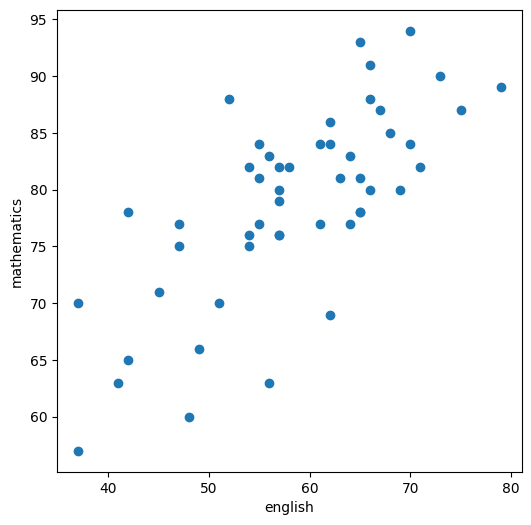

In [41]:
# 산점도

eng2 = np.array(df['english'])
math2 = np.array(df['mathematics'])

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(111)

ax.scatter(eng2, math2)
ax.set_xlabel('english')
ax.set_ylabel('mathematics')

plt.show()

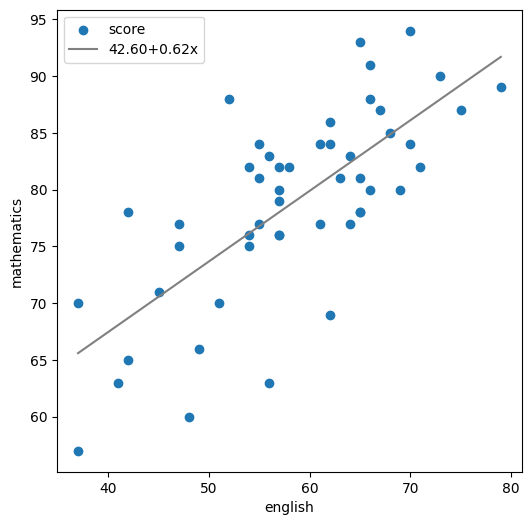

In [44]:
#회귀직선

# 계수β_0와β_1를 구한다
poly_fit = np.polyfit(eng2, math2, 1)
# β_0+β_1 x를 반환하는 함수를 작성
poly_1d = np.poly1d(poly_fit)
# 직선을 그리기 위해 x좌표를 생성
xs = np.linspace(eng2.min(), eng2.max())
# xs에 대응하는 y좌표를 구한다
ys = poly_1d(xs)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)
ax.set_xlabel('english')
ax.set_ylabel('mathematics')
ax.scatter(eng2, math2, label='score')
ax.plot(xs, ys, color='gray',
        label=f'{poly_fit[1]:.2f}+{poly_fit[0]:.2f}x')
# 범례의 표시
ax.legend(loc='upper left')

plt.show()

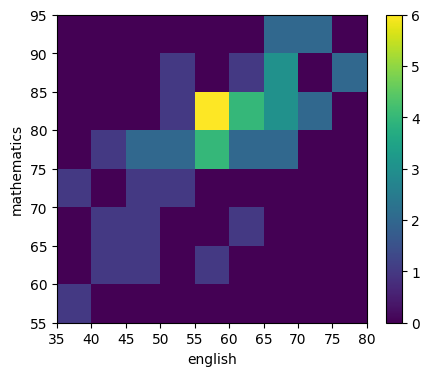

In [46]:
#히트맵 : 히스토그램의 2차원 버전, 색상 이용한 그래프

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111)

c = ax.hist2d(eng2, math2, bins = [9,8], range = [(35, 80), (55, 95)])
ax.set_xlabel('english')
ax.set_ylabel('mathematics')
ax.set_xticks(c[1])
ax.set_yticks(c[2])
fig.colorbar(c[3], ax = ax)

plt.show()

- 앤스컴 (예)

In [193]:
# npy 형식으로 저장된 NumPy array를 읽어들인다
anscombe_data = np.load('../통계분석2/받은 파일/data/ch3_anscombe.npy')
print(anscombe_data.shape)
anscombe_data[0]

(4, 11, 2)


array([[10.  ,  8.04],
       [ 8.  ,  6.95],
       [13.  ,  7.58],
       [ 9.  ,  8.81],
       [11.  ,  8.33],
       [14.  ,  9.96],
       [ 6.  ,  7.24],
       [ 4.  ,  4.26],
       [12.  , 10.84],
       [ 7.  ,  4.82],
       [ 5.  ,  5.68]])

In [194]:
stats_df = pd.DataFrame(index=['X_mean', 'X_variance', 'Y_mean',
                               'Y_variance', 'X&Y_correlation',
                               'X&Y_regression line'])
for i, data in enumerate(anscombe_data):
    dataX = data[:, 0]
    dataY = data[:, 1]
    poly_fit = np.polyfit(dataX, dataY, 1)
    stats_df[f'data{i+1}'] =\
        [f'{np.mean(dataX):.2f}',
         f'{np.var(dataX):.2f}',
         f'{np.mean(dataY):.2f}',
         f'{np.var(dataY):.2f}',
         f'{np.corrcoef(dataX, dataY)[0, 1]:.2f}',
         f'{poly_fit[1]:.2f}+{poly_fit[0]:.2f}x']
stats_df

,data1,data2,data3,data4
X_mean,9.00,9.00,9.00,9.00
X_variance,10.00,10.00,10.00,10.00
Y_mean,7.50,7.50,7.50,7.50
Y_variance,3.75,3.75,3.75,3.75
X&Y_correlation,0.82,0.82,0.82,0.82
X&Y_regression line,3.00+0.50x,3.00+0.50x,3.00+0.50x,3.00+0.50x


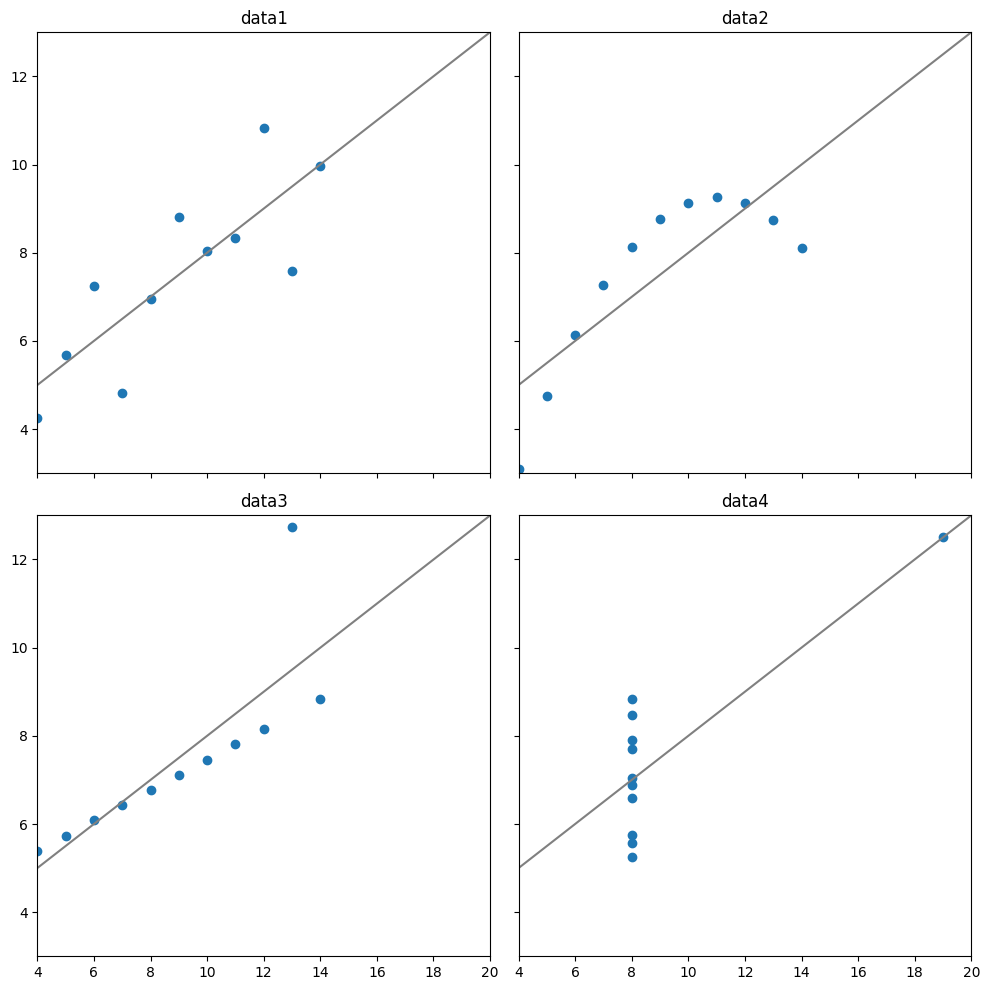

In [197]:
# 그래프를 그리기 위한 영역을 2x2개 생성
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10),
                         sharex=True, sharey=True)

xs = np.linspace(0, 30, 100)
for i, data in enumerate(anscombe_data):
    poly_fit = np.polyfit(data[:,0], data[:,1], 1)
    poly_1d = np.poly1d(poly_fit)
    ys = poly_1d(xs)
    # 그리는 영역을 선택
    ax = axes[i//2, i%2]
    ax.set_xlim([4, 20])
    ax.set_ylim([3, 13])
    # 타이틀을 부여
    ax.set_title(f'data{i+1}')
    ax.scatter(data[:,0], data[:,1])
    ax.plot(xs, ys, color='gray')

# 그래프 사이의 간격을 좁힘
plt.tight_layout()
plt.show()

## 히트맵 연습문제

##### 쿠팡/네이버페이 섞인 결제 로그로 요일 * 시간대 히트맵
##### - 요일(월~일) * 시간대(0~23시)
##### - 각 칸 값 = 순매출(걸제 - 환불) 합계
##### - 히트맵으로 [언제 매출이 몰리는지] 시각화

포함 항목
- 날짜 파싱을 여러 포맷으로 허용
- 금액에서 통화기호/콤마/원/괄호 텍스트 제거 후 숫자 변환
- refund/cancel은 음수 처리(순매출 계산용)
- 플랫폼 표기를 통일(쿠팡/네이버페이 2개로 매핑할 것)
- 중복 order_id는 최신 기록만 남길 것
- 요일, 시간 컬럼 추가
- 요일*시간 피벗테이블 구성 후 히트맵
- (심화) 플랫폼별 히트맵을 2개의subplot으로 그릴 것

In [142]:
import numpy as np
import pandas as pd
import re
from datetime import datetime, timezone, timedelta

%precision 3
pd.set_option('display.float_format', '{:.3f}'.format)

dfs = pd.read_csv('../통계분석2/받은 파일/data/ch03_raw_big_orders.csv')
dfs

,order_id,order_time,platform,amount,status
0,O100000,2026/01/05 06:00 AM,네이버페이,"-₩33,000(환불)",refund
1,O100001,2026-01-19 03:00:00+09:00,쿠팡,"₩12,900",paid
2,O100002,2026-01-12 06:00:00+09:00,기타,"-₩12,900",cancel
3,O100003,2026-01-05 10:00:00+09:00,쿠팡,"₩45,000",paid
4,O100004,2026-01-03 23:00:00+09:00,쿠팡,"-₩12,900(환불)",refund
...,...,...,...,...,...
3995,O103995,2026/01/06 11:00 AM,쿠팡,"-₩19,800(환불)",refund
3996,O103996,2026-01-04 11:00:00+09:00,Npay,"₩45,000",paid
3997,O103997,2026-01-17 14:00:00+09:00,쿠팡,"₩19,800",paid
3998,O103998,NaN,네이버페이,8900원,paid


In [187]:
#모든 값이 str -> order_id에 원 처리 후 int, order_time은 날짜, 시간별로 (없는 건 dropna)
#amount기호 및 str 처리 후 int로 변경, platform 통일화 (기타 빼기?)

df = dfs.copy()
df['id_int'] = df['order_id'].str.replace(r'[^0-9]', '', regex = True).astype(int)

df['new_order_day'] = df['order_time'].str.split().str[0]
df['new_order_time'] = df['order_time'].str.split().str[1:]

df['new_order_day'] = df['new_order_day'].str.replace(r'[/-]', ' ', regex = True)
df = df[df['new_order_day'] != 'NaN']
df['year'] = df['new_order_day'].str.split().str[0]
df['month'] = df['new_order_day'].str.split().str[1]
df['day'] = df['new_order_day'].str.split().str[2]
df

,order_id,order_time,platform,amount,status,id_int,new_order_day,new_order_time,year,month,day
0,O100000,2026/01/05 06:00 AM,네이버페이,"-₩33,000(환불)",refund,100000,2026 01 05,"[06:00, AM]",2026,01,05
1,O100001,2026-01-19 03:00:00+09:00,쿠팡,"₩12,900",paid,100001,2026 01 19,[03:00:00+09:00],2026,01,19
2,O100002,2026-01-12 06:00:00+09:00,기타,"-₩12,900",cancel,100002,2026 01 12,[06:00:00+09:00],2026,01,12
3,O100003,2026-01-05 10:00:00+09:00,쿠팡,"₩45,000",paid,100003,2026 01 05,[10:00:00+09:00],2026,01,05
4,O100004,2026-01-03 23:00:00+09:00,쿠팡,"-₩12,900(환불)",refund,100004,2026 01 03,[23:00:00+09:00],2026,01,03
...,...,...,...,...,...,...,...,...,...,...,...
3995,O103995,2026/01/06 11:00 AM,쿠팡,"-₩19,800(환불)",refund,103995,2026 01 06,"[11:00, AM]",2026,01,06
3996,O103996,2026-01-04 11:00:00+09:00,Npay,"₩45,000",paid,103996,2026 01 04,[11:00:00+09:00],2026,01,04
3997,O103997,2026-01-17 14:00:00+09:00,쿠팡,"₩19,800",paid,103997,2026 01 17,[14:00:00+09:00],2026,01,17
3998,O103998,NaN,네이버페이,8900원,paid,103998,NaN,NaN,NaN,NaN,NaN


In [189]:
df['new_amount'] = df['amount'].str.replace(r'[^0-9]', '', regex=True)
# print(df['new_amount'])
# print(df['amount'])

# print(df[df['status'] == 'cancel'])
# print(df[df['status'] == 'refund'])
# print(df[df['status'] == 'paid'])
순매출 = 0
for i in range(df['amount'].count()):
    if df['status'][i] == 'cancel' or df['status'][i] == 'refund':
        df['new_amount'][i] = 0 - int(df['new_amount'][i])
        순매출 += df['new_amount'][i]
    else:
        순매출 += int(df['new_amount'][i])

print(df)
print("순매출 > ", 순매출)

     order_id                 order_time platform        amount  status  \
0     O100000        2026/01/05 06:00 AM    네이버페이  -₩33,000(환불)  refund   
1     O100001  2026-01-19 03:00:00+09:00       쿠팡       ₩12,900    paid   
2     O100002  2026-01-12 06:00:00+09:00       기타      -₩12,900  cancel   
3     O100003  2026-01-05 10:00:00+09:00       쿠팡       ₩45,000    paid   
4     O100004  2026-01-03 23:00:00+09:00       쿠팡  -₩12,900(환불)  refund   
...       ...                        ...      ...           ...     ...   
3995  O103995        2026/01/06 11:00 AM       쿠팡  -₩19,800(환불)  refund   
3996  O103996  2026-01-04 11:00:00+09:00     Npay       ₩45,000    paid   
3997  O103997  2026-01-17 14:00:00+09:00       쿠팡       ₩19,800    paid   
3998  O103998                        NaN    네이버페이         8900원    paid   
3999  O103999  2026-01-05 12:00:00+09:00       기타         8900원    paid   

      id_int new_order_day    new_order_time  year month  day   요일     시간  \
0     100000    2026-0

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14164\3486563210.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['new_amount'][i] = 0 - int(df['new_amount'][i])
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14164\34

In [190]:
print('원래 것 > ', df['platform'].unique())

df['platform_new'] = df['platform'].str.replace('Npay', '네이버페이').str.replace('coupang', '쿠팡')
print('변환한 것 > ', df['platform_new'].unique())

원래 것 >  ['네이버페이' '쿠팡' '기타' 'Npay' 'coupang']
변환한 것 >  ['네이버페이' '쿠팡' '기타']


In [191]:
df = df.sort_values(by='id_int', ascending=False)
# df['id_int'].unique()
df = df.drop_duplicates(subset=['id_int'], keep='first')
df = df.sort_values(by='id_int', ascending=True)
df

,order_id,order_time,platform,amount,status,id_int,new_order_day,new_order_time,year,month,day,요일,시간,new_amount,platform_new
0,O100000,2026/01/05 06:00 AM,네이버페이,"-₩33,000(환불)",refund,100000,2026-01-05,"[06:00, AM]",2026,01,05,월,06:00,-33000,네이버페이
1,O100001,2026-01-19 03:00:00+09:00,쿠팡,"₩12,900",paid,100001,2026-01-19,[03:00:00+09:00],2026,01,19,월,03:00,12900,쿠팡
2,O100002,2026-01-12 06:00:00+09:00,기타,"-₩12,900",cancel,100002,2026-01-12,[06:00:00+09:00],2026,01,12,월,06:00,-12900,기타
3,O100003,2026-01-05 10:00:00+09:00,쿠팡,"₩45,000",paid,100003,2026-01-05,[10:00:00+09:00],2026,01,05,월,10:00,45000,쿠팡
4,O100004,2026-01-03 23:00:00+09:00,쿠팡,"-₩12,900(환불)",refund,100004,2026-01-03,[23:00:00+09:00],2026,01,03,토,23:00,-12900,쿠팡
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,O103995,2026/01/06 11:00 AM,쿠팡,"-₩19,800(환불)",refund,103995,2026-01-06,"[11:00, AM]",2026,01,06,화,11:00,-19800,쿠팡
3996,O103996,2026-01-04 11:00:00+09:00,Npay,"₩45,000",paid,103996,2026-01-04,[11:00:00+09:00],2026,01,04,일,11:00,45000,네이버페이
3997,O103997,2026-01-17 14:00:00+09:00,쿠팡,"₩19,800",paid,103997,2026-01-17,[14:00:00+09:00],2026,01,17,토,14:00,19800,쿠팡
3998,O103998,NaN,네이버페이,8900원,paid,103998,NaT,NaN,NaN,NaN,NaN,NaN,None,8900,네이버페이


In [188]:
df['new_order_day'], df['new_order_time']
KST = timezone(timedelta(hours=9))
now = datetime.now(KST)
week = ['월', '화', '수', '목', '금', '토', '일']

df['new_order_day'] = pd.to_datetime(df['new_order_day'], errors='coerce')
df['요일'] = df['new_order_day'].dt.weekday.map(lambda x: 
                                              week[int(x)] if pd.notna(x) else np.nan)

parsed_times = []
for i in df.index:
    row = df.loc[i, 'new_order_time']

    if not isinstance(row, list):
        parsed_times.append(None)
        continue
    
    if len(row) == 0:
        parsed_times.append(None)
        continue

    try:
        if len(row) == 2 and row[1] in ['AM', 'PM']:
            time_part = row[0]  # "06:00"
            ampm = row[1]       # "PM"
            hour = int(time_part.split(':')[0])
            minute = int(time_part.split(':')[1])
            
            if ampm == 'PM' and hour < 12:
                hour += 12
            elif ampm == 'AM' and hour == 12:
                hour = 0
            parsed_times.append(f"{hour:02d}:{minute:02d}") 
        else:
            time_part = row[0] # "06:00:00+09:00"
            clean_time = time_part.split('+')[0]
            hour_min = ":".join(clean_time.split(':')[:2])
            parsed_times.append(hour_min)
    except:
        parsed_times.append(None)

df['시간'] = parsed_times
print(df[['new_order_day', '요일', '시간']].head())
df

  new_order_day 요일     시간
0    2026-01-05  월  06:00
1    2026-01-19  월  03:00
2    2026-01-12  월  06:00
3    2026-01-05  월  10:00
4    2026-01-03  토  23:00


,order_id,order_time,platform,amount,status,id_int,new_order_day,new_order_time,year,month,day,요일,시간
0,O100000,2026/01/05 06:00 AM,네이버페이,"-₩33,000(환불)",refund,100000,2026-01-05,"[06:00, AM]",2026,01,05,월,06:00
1,O100001,2026-01-19 03:00:00+09:00,쿠팡,"₩12,900",paid,100001,2026-01-19,[03:00:00+09:00],2026,01,19,월,03:00
2,O100002,2026-01-12 06:00:00+09:00,기타,"-₩12,900",cancel,100002,2026-01-12,[06:00:00+09:00],2026,01,12,월,06:00
3,O100003,2026-01-05 10:00:00+09:00,쿠팡,"₩45,000",paid,100003,2026-01-05,[10:00:00+09:00],2026,01,05,월,10:00
4,O100004,2026-01-03 23:00:00+09:00,쿠팡,"-₩12,900(환불)",refund,100004,2026-01-03,[23:00:00+09:00],2026,01,03,토,23:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,O103995,2026/01/06 11:00 AM,쿠팡,"-₩19,800(환불)",refund,103995,2026-01-06,"[11:00, AM]",2026,01,06,화,11:00
3996,O103996,2026-01-04 11:00:00+09:00,Npay,"₩45,000",paid,103996,2026-01-04,[11:00:00+09:00],2026,01,04,일,11:00
3997,O103997,2026-01-17 14:00:00+09:00,쿠팡,"₩19,800",paid,103997,2026-01-17,[14:00:00+09:00],2026,01,17,토,14:00
3998,O103998,NaN,네이버페이,8900원,paid,103998,NaT,NaN,NaN,NaN,NaN,NaN,None


#### ---------------------------------------

# Ch04 추측통계의 기본
- 모집단과 표본

In [198]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%precision 3
%matplotlib inline

In [199]:
#표본 추출 방법
df = pd.read_csv('../통계분석2/받은 파일/data/ch4_scores400.csv')
scores = np.array(df['score'])
scores[:10]

array([76, 55, 80, 80, 74, 61, 81, 76, 23, 80])

In [206]:
#무작위 추출(임의 추출) : 임의로 표본을 추출함
#복원추출 : 여러 차례 동일 표본을 선택
np.random.choice([1, 2, 3], 3)

#비복원추출 : 동일 표본은 한 번만 선택
np.random.choice([1, 2, 3], 3, replace=False)

#시드 지정할 경우 무작위(임의) 추출은 항상 같은 결과
np.random.seed(0)
np.random.choice([1, 2, 3], 3)

#표본크기 20으로 복원추출, 표본 평균 계산
np.random.seed(0)
sample = np.random.choice(scores, 20)

sample.mean() #70.400 -> 표본평균
scores.mean() #69.530 -> 모평균

# -> 무작위 추측은 실행 때마다 결과 달라 표본평균도 매번 다름
for i in range(5):
    sample = np.random.choice(scores, 20)
    print(f'{i+1}번째 무작위 추출로 얻은 표본평균', sample.mean())

1번째 무작위 추출로 얻은 표본평균 72.45
2번째 무작위 추출로 얻은 표본평균 63.7
3번째 무작위 추출로 얻은 표본평균 66.05
4번째 무작위 추출로 얻은 표본평균 71.7
5번째 무작위 추출로 얻은 표본평균 74.15


- 확률 모형

    - 확률 : 무작위 추출과 같은 불확정성 수반한 현상을 해석하는 것
    - 확률 모형 : 무작위 추출 or 주사위 모델링(모형)
    - 확률변수 : 결과는 모르지만, 취하는 갓과 그 값이 나올 확률이 결정됨
    - 시행 : 확률변수의 결과 관측하는 것
    - 실현값 : 시행에 의해 관측된 값
    - 사건 : 시행 결과로 나타날 수 있는 값
    - 근원사건 : 세부적으로 더 분해 불가한 사건
    - 상호배반 : 동시에 일어날 수 없는 사건

In [207]:
#파이썬으로 불공정한 주사위 확률분포를 구하는 방법
dice = [1, 2, 3, 4, 5, 6]
prob = [1/21, 2/21, 3/21, 4/21, 5/21, 6/21]

np.random.choice(dice, p=prob)

num_trial = 100
sample = np.random.choice(dice, num_trial, p=prob)
sample

array([4, 6, 4, 5, 5, 6, 6, 3, 5, 6, 5, 6, 6, 2, 3, 1, 6, 5, 6, 3, 4, 5,
       3, 4, 3, 5, 5, 4, 4, 6, 4, 6, 5, 6, 5, 4, 6, 2, 6, 4, 5, 3, 4, 6,
       5, 5, 5, 3, 4, 5, 4, 4, 6, 4, 4, 6, 6, 2, 2, 4, 5, 1, 6, 4, 3, 2,
       2, 6, 3, 5, 4, 2, 4, 4, 6, 6, 1, 5, 3, 6, 6, 4, 2, 1, 6, 4, 4, 2,
       4, 1, 3, 6, 6, 6, 4, 5, 4, 3, 3, 4])

In [208]:
#도수분포표와 히스토그램
freq, _ = np.histogram(sample, bins=6, range=(1, 7))
pd.DataFrame({'frequency':freq,
              'relative frequency':freq / num_trial},
              index = pd.Index(np.arange(1, 7), name='dice'))

,frequency,relative frequency
dice,,
1,5,0.050
2,9,0.090
3,13,0.130
4,27,0.270
5,19,0.190
6,27,0.270


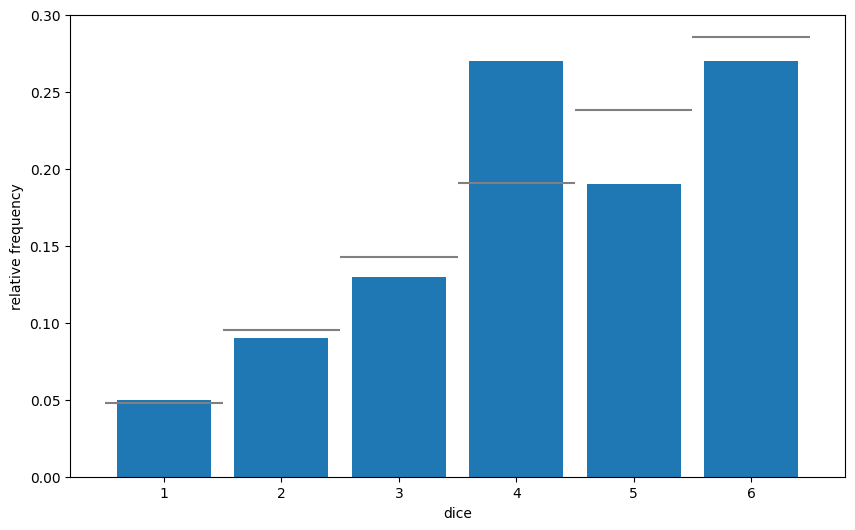

In [209]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.hist(sample, bins=6, range=(1, 7), density=True, rwidth=0.8)
# 실제의 확률분포를 가로선으로 표시
ax.hlines(prob, np.arange(1, 7), np.arange(2, 8), colors='gray')
# 막대 그래프의 [1.5, 2.5, ..., 6.5]에 눈금을 표시
ax.set_xticks(np.linspace(1.5, 6.5, 6))
# 주사위 눈의 값은 [1, 2, 3, 4, 5, 6]
ax.set_xticklabels(np.arange(1, 7))
ax.set_xlabel('dice')
ax.set_ylabel('relative frequency')
plt.show()

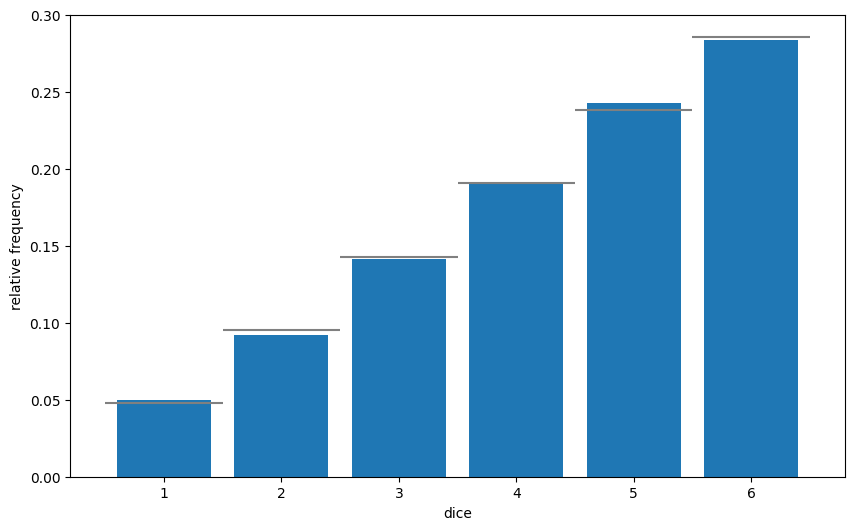

In [210]:
num_trial = 10000
sample = np.random.choice(dice, size=num_trial, p=prob)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.hist(sample, bins=6, range=(1, 7), density=True, rwidth=0.8)
ax.hlines(prob, np.arange(1, 7), np.arange(2, 8), colors='gray')
ax.set_xticks(np.linspace(1.5, 6.5, 6))
ax.set_xticklabels(np.arange(1, 7))
ax.set_xlabel('dice')
ax.set_ylabel('relative frequency')
plt.show()

- 추측통계의 확률

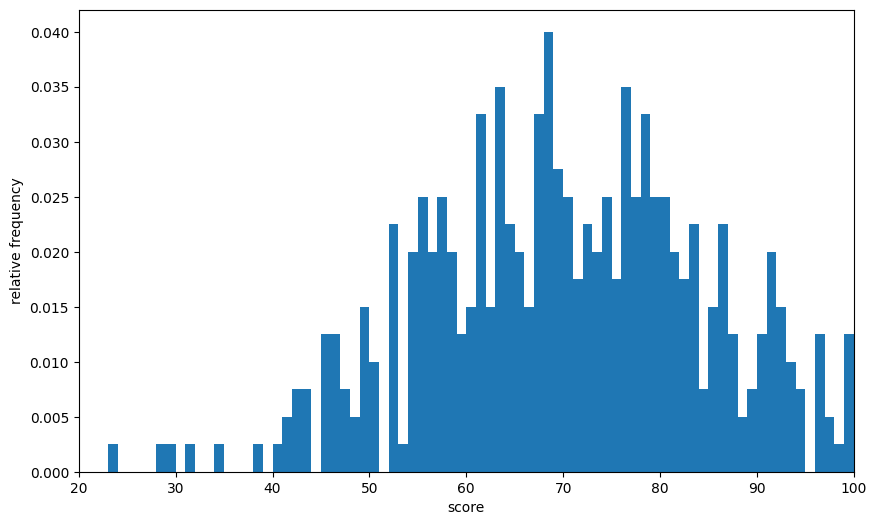

In [211]:
#계급폭이 1점인 히스토그램
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.hist(scores, bins=100, range=(0, 100), density=True)
ax.set_xlim(20, 100)
ax.set_ylim(0, 0.042)
ax.set_xlabel('score')
ax.set_ylabel('relative frequency')
plt.show()

In [212]:
np.random.choice(scores)

np.int64(89)

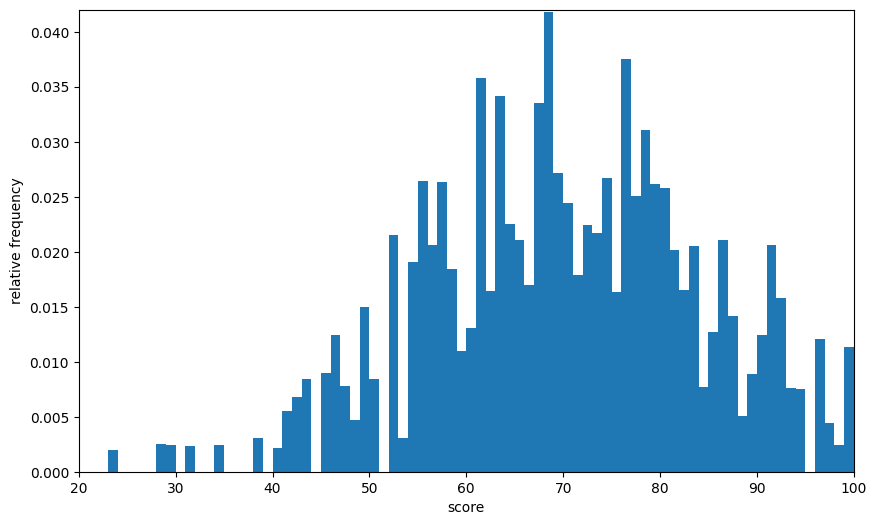

In [213]:
sample = np.random.choice(scores, 10000)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.hist(sample, bins=100, range=(0, 100), density=True)
ax.set_xlim(20, 100)
ax.set_ylim(0, 0.042)
ax.set_xlabel('score')
ax.set_ylabel('relative frequency')
plt.show()

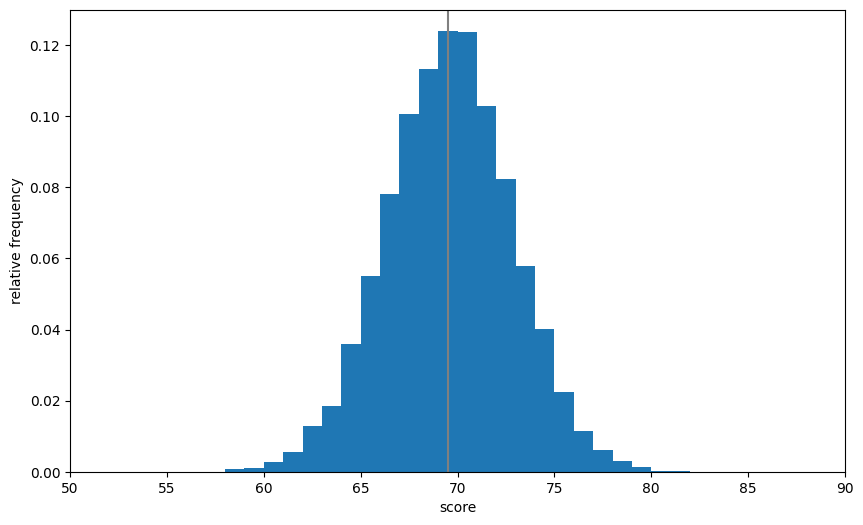

In [214]:
sample_means = [np.random.choice(scores, 20).mean()
                for _ in range(10000)]

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.hist(sample_means, bins=100, range=(0, 100), density=True)
# 모평균을 세로선으로 표시
ax.vlines(np.mean(scores), 0, 1, 'gray')
ax.set_xlim(50, 90)
ax.set_ylim(0, 0.13)
ax.set_xlabel('score')
ax.set_ylabel('relative frequency')
plt.show()

- ## 배달 앱 연습문제

##### 주문 후 실제 배달 완료까지 걸린 시간(분) 분석

포함 항목
- 배달시간은 어떤 확률분포를 갖는가?
- 무작위로 주문을 하나 뽑으면 어떤 시간이 나올 가능성이 높나?
- 표본을 많이 뽑으면 실제 분포를 알 수 있을까?
- 표본평균으로 평균 배달시간을 추정할 수 있나?

##### ** 데이터 정제, 결측치 및 이상치 처리, 분석 목적에 맞는 변수 정의는 알아서

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%precision 3
pd.set_option('display.float_format', '{:.3f}'.format)

In [78]:
deli = pd.read_csv('../통계분석2/받은 파일/data/ch04_delivery_time.csv')
deli

,order_id,delivery_time_raw,status
0,1,38.97371322408986,completed
1,2,NaN,completed
2,3,NaN,completed
3,4,47.184238851264205,completed
4,5,33.12677300221331,completed
...,...,...,...
1555,1180,41.75692819341075,completed
1556,461,50.717801063331116,completed
1557,1352,NaN,completed
1558,422,49.042726739545635,completed


In [79]:
deli['status'].unique()
deli[deli['status'] == 'cancelled']

,order_id,delivery_time_raw,status
18,19,27.735807395830314,cancelled
60,61,180,cancelled
84,85,28.532051176854498,cancelled
91,92,42.74915992426311,cancelled
97,98,37.08844217743911,cancelled
...,...,...,...
1466,1467,161.74761260878515,cancelled
1471,1472,104.75542739201545,cancelled
1495,1496,170.1523222039781,cancelled
1500,92,42.74915992426311,cancelled


In [86]:
#order_id	delivery_time_raw	status -> int   str     str
# delivery_time_raw str -> int로 변경 필요

deli['delivery_time'] = deli['delivery_time_raw'].copy()
# lst = []
# for i in deli.index:
#     row = deli.loc[i, 'delivery_time']
#     if not isinstance(row, str):
#         lst.append(None)
#         continue
#     # if len(row) == 0:
#     #     lst.append(None)
#     #     continue
#     try:
#         nums = re.findall(r'\d+', row)
#         if not nums:
#             lst.append(None)
#         else:
#             lst.append(int(nums[0]))
#     except:
#         lst.append(None)
# deli['delivery_time'] = lst
deli['delivery_time'] = (
    deli['delivery_time']
    .str.extract(r'(\d+)')
    .astype(float)
    .astype('Int64')
)

# deli = deli['order_id'].sort_values(ascending = True)
deli

,order_id,delivery_time_raw,status,delivery_time
0,1,38.97371322408986,completed,38
1,2,NaN,completed,<NA>
2,3,NaN,completed,<NA>
3,4,47.184238851264205,completed,47
4,5,33.12677300221331,completed,33
...,...,...,...,...
1555,1180,41.75692819341075,completed,41
1556,461,50.717801063331116,completed,50
1557,1352,NaN,completed,<NA>
1558,422,49.042726739545635,completed,49


- 추정: 배달 시간이 길수록 캔슬할 확률이 높은가?
    - 길수록 캔슬 -> + 상관
    - 길수록 캔슬X -> - 상관
    - 길수록 모름 -> 무상관

In [96]:
freq = (
    deli
    .groupby(['delivery_time', 'status'])
    .size()
    .reset_index(name='frequency')
)

freq

,delivery_time,status,frequency
0,0,cancelled,1
1,0,completed,26
2,5,cancelled,1
3,5,completed,25
4,9,completed,1
...,...,...,...
136,171,completed,2
137,180,cancelled,1
138,180,completed,30
139,183,completed,1


In [114]:
#아래는 한글을 사용할 때 깨지는 문제에 대한 해결
from matplotlib import font_manager, rc
font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family=font_name)

#그래프의 축 등에서 음수를 표시할 때 minus sign이 깨지는 것 해결
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False

In [125]:
deli['time_bin'] = pd.cut(
    deli['delivery_time'],
    bins=range(0, deli['delivery_time'].max() + 10, 10),
    right=False
)

freq_bin = (
    deli
    .groupby(['time_bin', 'status'])
    .size()
    .reset_index(name='frequency')
)

pivot = freq_bin.pivot(
    index='time_bin',
    columns='status',
    values='frequency'
).fillna(0).sort_index() # 0이 받은 것, 1이 캔슬한 것

pivot['total'] = pivot['completed'] + pivot['cancelled']
pivot['complete_rate'] = pivot['completed'] / pivot['total'] #성공률
pivot['cancel_rate'] = pivot['cancelled'] / pivot['total'] #취소율

freq_bin

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_7996\3976475451.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['time_bin', 'status'])


,time_bin,status,frequency
0,"[0, 10)",cancelled,2
1,"[0, 10)",completed,52
2,"[10, 20)",cancelled,2
3,"[10, 20)",completed,21
4,"[20, 30)",cancelled,14
5,"[20, 30)",completed,206
6,"[30, 40)",cancelled,27
7,"[30, 40)",completed,467
8,"[40, 50)",cancelled,16
9,"[40, 50)",completed,343


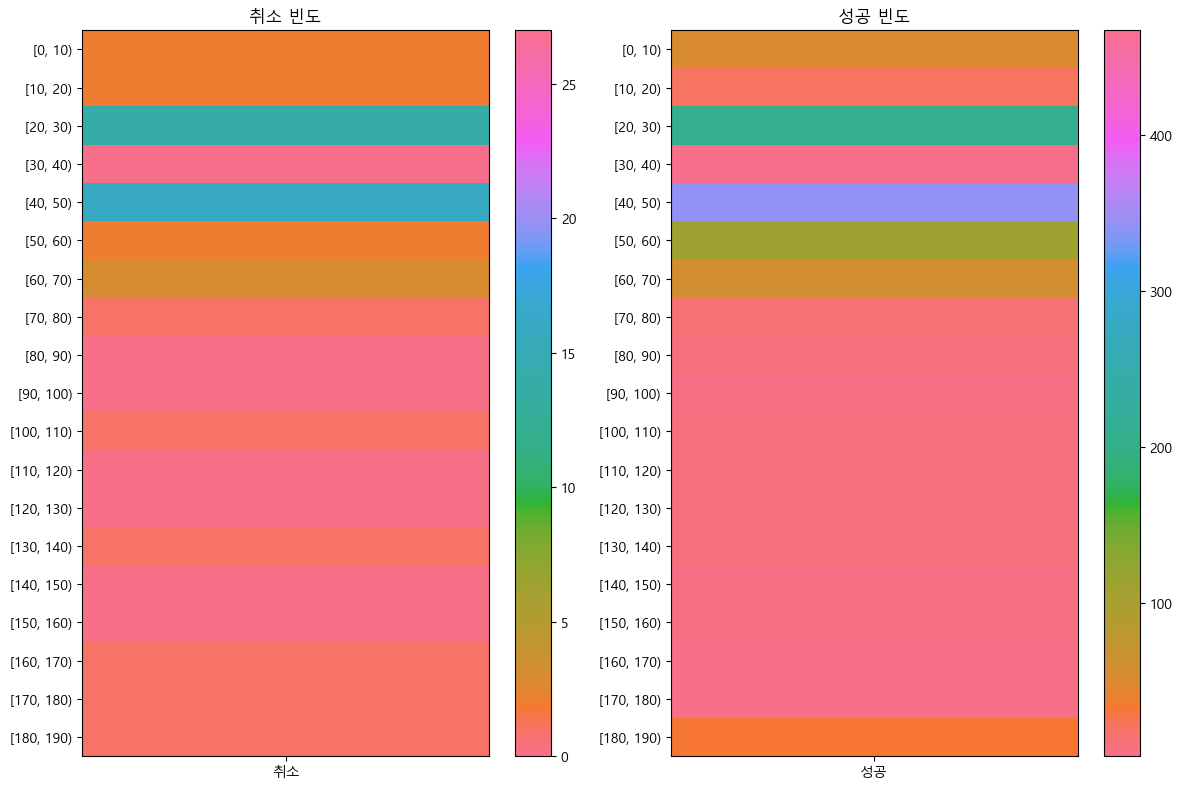

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
colors = sns.color_palette("husl", as_cmap=True)

im1 = ax1.imshow(pivot['cancelled'].values.reshape(-1, 1), aspect='auto', cmap = colors)
ax1.set_title('취소 빈도')
ax1.set_yticks(range(len(pivot.index)))
ax1.set_yticklabels(pivot.index)
ax1.set_xticks([0])
ax1.set_xticklabels(['취소'])

fig.colorbar(im1, ax=ax1)

im2 = ax2.imshow(pivot['completed'].values.reshape(-1, 1), aspect='auto', cmap = colors)
ax2.set_title('성공 빈도')
ax2.set_yticks(range(len(pivot.index)))
ax2.set_yticklabels(pivot.index)
ax2.set_xticks([0])
ax2.set_xticklabels(['성공'])

fig.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

#컬러 바의 의미는 취소/성공의 빈도수(올라갈수록 많이 취소/성공)
#취소/성공 모두 단시간(20~30분, 20~50분)에 빈도 수가 많은 편임
#

- 표본을 뽑아서 다음을 실행:
    - 표본을 많이 뽑으면 실제 분포를 알 수 있을까?
    - 표본평균으로 평균 배달시간을 추정할 수 있나?

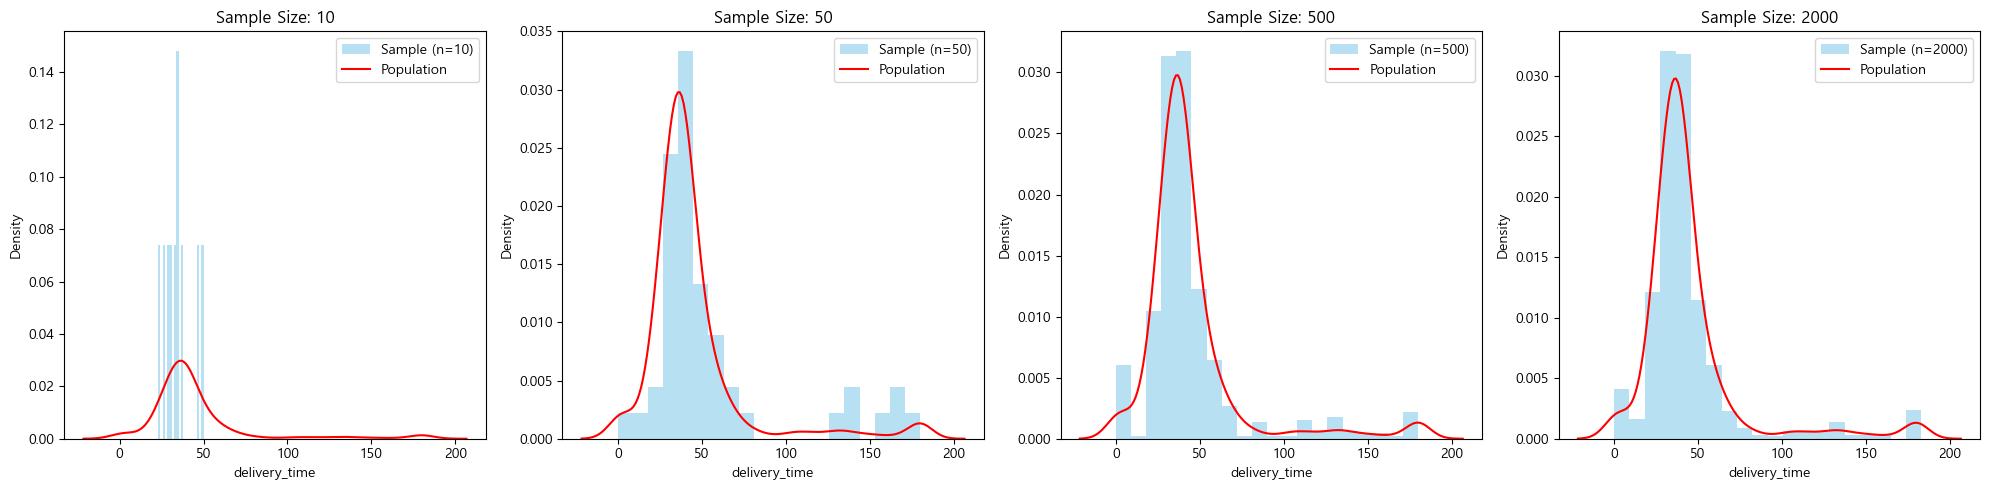

In [136]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 모집단 설정 (전체 배달 시간 데이터)
population = deli['delivery_time'].dropna()

# 2. 다양한 표본 크기(n)로 실험
sample_sizes = [10, 50, 500, 2000]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, n in enumerate(sample_sizes):
    # n개만큼 무작위 추출
    sample = np.random.choice(population, size=n, replace=True)
    
    axes[i].hist(sample, bins=20, density=True, alpha=0.6, color='skyblue', label=f'Sample (n={n})')
    axes[i].set_title(f'Sample Size: {n}')
    
    # 비교를 위해 모집단의 선 그래프(KDE) 추가
    sns.kdeplot(population, ax=axes[i], color='red', bw_adjust=1, label='Population')
    axes[i].legend()

plt.tight_layout()
plt.show()

모집단의 실제 평균 배달 시간: 44.42분


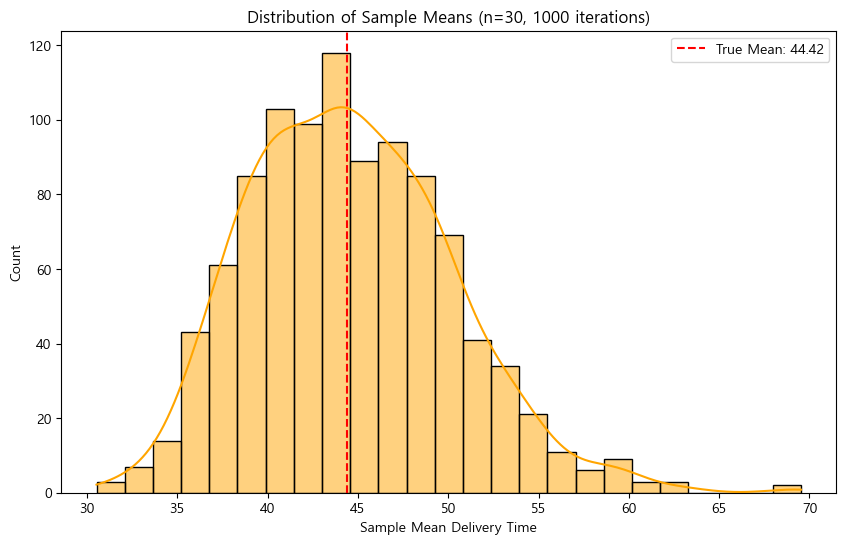

표본평균들의 평균: 44.61


In [137]:
# 1. 모집단의 진짜 평균 계산
true_mean = population.mean()
print(f"모집단의 실제 평균 배달 시간: {true_mean:.2f}분")

# 2. 표본평균 추출 실험
# (한 번에 30개씩 뽑아서 평균 내기)를 1000번 반복
n = 30
it_count = 1000
sample_means = [np.random.choice(population, size=n).mean() for _ in range(it_count)]

# 3. 결과 시각화
plt.figure(figsize=(10, 6))
sns.histplot(sample_means, kde=True, color='orange')
plt.axvline(true_mean, color='red', linestyle='--', label=f'True Mean: {true_mean:.2f}')
plt.title(f'Distribution of Sample Means (n={n}, {it_count} iterations)')
plt.xlabel('Sample Mean Delivery Time')
plt.legend()
plt.show()

# 4. 표본평균들의 평균 확인
print(f"표본평균들의 평균: {np.mean(sample_means):.2f}")